## Port accessibility - tidal downtime (multiple nodes)
In this notebook, we set up a basic simulation in which a vessel bound from sea navigates a tidal waterway (consisting of multiple nodes) to reach a terminal in a port. At the terminal, the vessel berths, unloads cargo, and deberths, after it sails back to sea. During the passage of the waterway, the vessel is prone to a tidal window. This notebook visualises and calculates these tidal windows. Using the same parameters as in notebook 0300, will the tidal windows change?

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
from pyproj import Geod
from shapely.geometry import Point, LineString

# package(s) related to the hydrodynamics and tidal windows
import xarray as xr

# load OpenTNSim core mixins
from opentnsim.core import Identifiable, Movable, VesselProperties
from opentnsim.core.utils import create_object

# load OpenTNSim environment mixin to add hydrodynamic data to the environment
from opentnsim.environment.mixins.hydrodynamics import HydrodynamicData

# load OpenTNSim graph utils
from opentnsim.graph.calculations import calculate_distance_along_path
from opentnsim.graph.visualizations import plot_graph

# load OpenTNSim port module mixins and utils
from opentnsim.port.mixins.rules import Rule, TrafficRules
from opentnsim.port.mixins.tidal_accessibility import HasDraughtRestrictions
from opentnsim.port.mixins.anchorage_area import IsAnchorage, CanWaitAtAnchorage
from opentnsim.port.mixins.port import IsPort, HasPortAccess
from opentnsim.port.mixins.berth import IsJetty
from opentnsim.port.mixins.terminal import IsTerminal, TerminalHandable
from opentnsim.port.utils import (
    add_ukc_policy_to_node, 
    add_traffic_encountering_restriction_to_edge, 
    add_traffic_encountering_exception_to_edge,
    add_traffic_overtaking_restriction_to_edge, 
    add_traffic_reservation_to_edge,
    )

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# package(s) needed for inspecting the output
import pandas as pd
import numpy as np

# package(s) for plotting
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.3.2a2.dev3+g514a752b4.d20260603


#### Define input
graph

In [2]:
number_of_nodes = 11

vessel

In [3]:
vessel_length = 300
vessel_beam = 40
vessel_draught = 14.2
vessel_speed = 4.5 #m/s

infrastructure

In [4]:
waterway_length = 30000 #meters
waterway_depth = 15 #meters (NGD: nautical guaranteed depth = MBL: maintained bed level)

harbour_basin_depth = 16.5
anchorage_area_depth = 17

tide

In [5]:
tidal_period = 12.5 #hours
tidal_range_sea = 2.0 #meters
tidal_propagation_speed = np.sqrt(9.81*waterway_depth) #meters per second (np.sqrt(grav_acc*waterway_depth)), grav_acc=9.81
tidal_amplication = 0.8 #amplification factor

tidal restrictions

In [6]:
#percentage of the draught as UKC (10% of draught is common)
ukc_percentage = 10.0 * np.ones(number_of_nodes) #% of draught 

#static value as UKC (0.5 m is common, but not in combination with ukc_percentage)
ukc_static = 0.0 * np.ones(number_of_nodes) #meters

#freshwater allowance as percentage of draught as additional UKC: saltwater at sea (no sinkage), fresher water in port (5% extra sinkage common)
fwa = 0.0 * np.ones(number_of_nodes) #% of draught 

#### 0. Create environment

In [7]:
# set simulation time
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
simulation_stop = datetime.datetime(2024, 1, 8, 0, 0, 0)

# create time series aligned with simulation time
timestep = pd.Timedelta(minutes=5)
time_series = pd.date_range(simulation_start,simulation_stop,freq=timestep)

env = simpy.Environment(initial_time=simulation_start.timestamp())
env.simulation_start = simulation_start
env.simulation_stop = simulation_stop
env.epoch = simulation_start

#### 1. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we create a single edge of 100 km exactly.

In [8]:
# initialize geodetic calculator with WGS84 ellipsoid
geod = Geod(ellps="WGS84")

In [9]:
# starting point (longitude, latitude)
coordinates_sea = (0,0)

# compute the other point 100 km East from Point 0
coordinates_waterway = {}
coordinates_waterway[0] = coordinates_sea
coordinates_previous_node = coordinates_sea
for node in range(number_of_nodes-1):
    coordinates_node = geod.fwd(coordinates_previous_node[0], coordinates_previous_node[1], 90 ,waterway_length/(number_of_nodes-1)) #east from previous node
    coordinates_waterway[node+1] = (coordinates_node[0],coordinates_node[1])
    coordinates_previous_node = coordinates_node

In [10]:
# create list of edges
edges = []
for node_start,node_stop in zip(range(0,number_of_nodes-1),range(1,number_of_nodes)):
    edges.append((node_start,node_stop))
    edges.append((node_stop,node_start))

In [11]:
# create a directed graph
graph = nx.DiGraph()

# add nodes
for name, coordinate in coordinates_waterway.items():
    graph.add_node(name, geometry=Point(coordinate[0], coordinate[1]))

# add edges
for edge in edges:
    waterway_geometry = LineString([Point(coordinates_waterway[edge[0]]),Point(coordinates_waterway[edge[1]])])
    graph.add_edge(edge[0], edge[1], geometry=waterway_geometry, weight=1, length_m=waterway_length/(number_of_nodes-1))

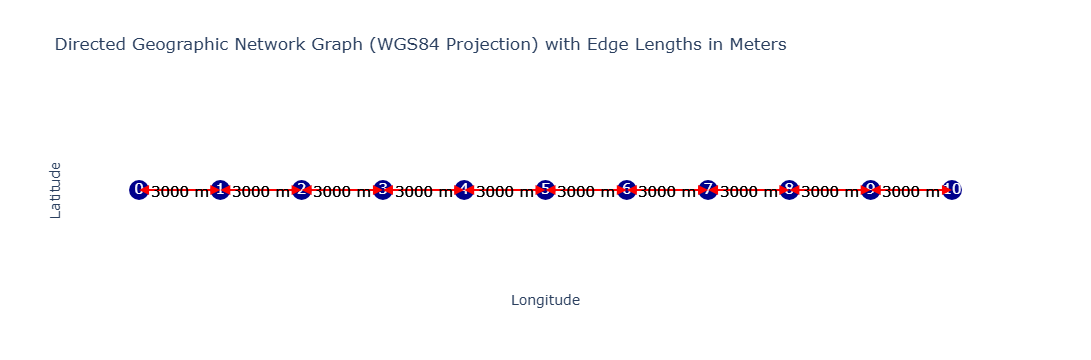

In [12]:
plot_graph(graph)

In [13]:
# add graph to environment
env.graph = graph

#### 1+ Adding environmental data

In [14]:
# create empty hydrodynamic dataset
hydrodynamic_data = xr.Dataset()

In [15]:
water_level_data = np.zeros((number_of_nodes,len(time_series)))
for node in graph.nodes:
    route_to_sea = nx.dijkstra_path(graph,0,node)
    distance_to_sea = 0.
    for node_start,node_stop in zip(route_to_sea[:-1],route_to_sea[1:]):
        distance_to_sea += graph.edges[node_start,node_stop]['length_m']

    amplification_factor = 1 - 0.2*(distance_to_sea/waterway_length)
    phase_shift = pd.Timedelta(seconds=distance_to_sea/tidal_propagation_speed)
    tidal_amplitude = amplification_factor*(tidal_range_sea/2)
    tidal_water_level = tidal_amplitude*np.sin(2*np.pi*((time_series-simulation_start-phase_shift)/(12.5*pd.Timedelta(hours=1))))
    water_level_data[node] = tidal_water_level
water_level_data_array = xr.DataArray(data=water_level_data,coords={'STATION':graph.nodes,'TIME':time_series})

In [16]:
MBL_data = -1*waterway_depth*np.ones([number_of_nodes,len(time_series)])
MBL_data_array = xr.DataArray(data=MBL_data,coords={'STATION':graph.nodes,'TIME':time_series})

In [17]:
hydrodynamic_data['Water level'] = water_level_data_array
hydrodynamic_data['Nautical depth'] = MBL_data_array

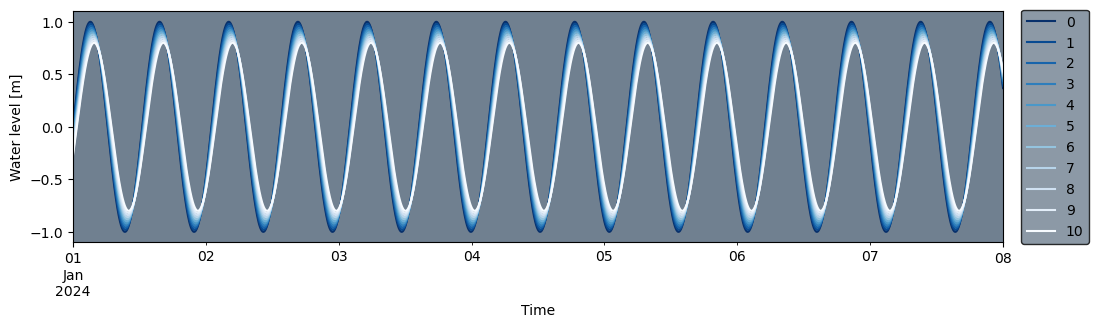

In [18]:
fig,ax = plt.subplots(figsize=[12,3])
ax.set_facecolor('slategray')
pd.DataFrame(hydrodynamic_data['Water level'].T,index=hydrodynamic_data['TIME']).plot(ax=ax,cmap='Blues_r')
ax.set_xlabel('Time')
ax.set_ylabel('Water level [m]')
ax.set_xlim(time_series[0],time_series[-1])
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.legend(loc='upper right',frameon=True,bbox_to_anchor=[1.1,1.0375],facecolor='slategray',edgecolor='k');

In [19]:
data = HydrodynamicData(env=env, hydrodynamic_data = hydrodynamic_data)

In [20]:
def ukc_policy(vessel):
    draught = vessel.T
    return draught * 0.1

In [21]:
for node in graph.nodes:
    if node not in hydrodynamic_data.STATION.values:
        continue
    
    # we create a list of Rule-objects that have a condition, policy, and name
    rules = [
        Rule(
            condition=lambda vessel: vessel.T >= 0., # condition (draught > 0, meaning the policy holds for all vessel)
            policy=ukc_policy, # policy
            name='ukc',
        ),
    ]

    # a built-in function that adds the rule(s) to the defined edge of the environment's graph
    add_ukc_policy_to_node(
        graph=env.graph,
        node=node,
        rules=rules,
    )

#### 1+ Adding infrastructure

In [22]:
port = IsPort(env=env, name = "Port", port_entry_nodes=[0])

In [23]:
anchorage = IsAnchorage(env=env, capacity=20, name = 'Anchorage', node = 0, depth = anchorage_area_depth, geometry=env.graph.nodes[0]['geometry'], port = port)

In [24]:
jetty = IsJetty(env=env,length=300, depth=harbour_basin_depth, name='Jetty',node=10)
terminal = IsTerminal(env=env, name = 'Terminal', berths=[jetty], port = port)

#### 2. Create agents

In [25]:
# make your preferred Vessel class out of available mix-ins.
Vessel = create_object(
    "Vessel", 
    (HasPortAccess,
     TerminalHandable,
     CanWaitAtAnchorage,
     HasDraughtRestrictions,
     Identifiable, # allows to give the object a name and a random ID,
     Movable,      # allows the object to move, with a fixed speed, while logging this activity
     VesselProperties,
    ), 
)

In [26]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    yield from vessel.move()

In [27]:
# create vessel from a dict 
path = nx.dijkstra_path(env.graph, 0, 10)
data_vessel = {
    "env": env,                                       # needed for simpy simulation
    "name": "Vessel 1",                               # required by Identifiable
    "geometry": env.graph.nodes[path[0]]['geometry'], # required by Locatable
    "route": path,                                    # required by Routeable
    "v": vessel_speed,                                # required by Movable, 1 m/s to check if the distance is covered in the expected time
    "bound": 'inbound',
    "terminal": terminal,
    "berthing_time":15, #minutes
    "loading_time": 12, #hours
    "deberthing_time":5, #minutes
    "next_destination":0,
    "type":"tanker",
    "L":vessel_length,
    "B":vessel_beam,
    "T":vessel_draught,
}  # 

# create an instance of the Vessel class using the input dict data_vessel
vessel = Vessel(**data_vessel)

# start the simulation
vessel.mission = env.process(mission(env, vessel))

#### 3. Run simulation

In [29]:
env.run()

In [30]:
data = {
    "Tide": [False, True, False, True, False, True, False, True, False, True],
    "Terminal": [True] * 10,
}

index = [
    "2024-01-01 00:00:00",
    "2024-01-01 01:10:00",
    "2024-01-01 03:25:00",
    "2024-01-01 13:40:00",
    "2024-01-01 15:55:00",
    "2024-01-02 02:10:00",
    "2024-01-02 04:25:00",
    "2024-01-02 14:40:00",
    "2024-01-02 16:55:00",
    "2024-01-08 00:00:00",
]

df = pd.DataFrame(data, index=pd.to_datetime(index))

In [31]:
def get_waiting_time_reason(lst):
    if not lst:
        return ""  # No False columns
    elif len(lst) == 1:
        return lst[0]
    else:
        return ", ".join(lst[:-1]) + " and " + lst[-1]

port_availability_df = df
port_availability_df['Reason'] = port_availability_df.apply(lambda row: get_waiting_time_reason(list(row.index[~row.values])),axis=1)

#### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [32]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel.logbook)

print("'{}' logbook data:".format(vessel.name))  
print('')

display(df)

if not df.empty:
    trip_distance = calculate_distance_along_path(graph, vessel.route)
    trip_duration = datetime.timedelta.total_seconds(vessel.logbook[-1]['Timestamp'] - vessel.logbook[0]['Timestamp'])
    print("'{}' travelled a distance of {:.1f} meters".format(vessel.name, trip_distance))
    print("'{}' took {:.1f} seconds to arrive at its destination".format(vessel.name, trip_duration)) 
    print("'{}' travelled at an average speed of {:.1f} meters per second".format(vessel.name, trip_distance/trip_duration))
else:
    print("The port was not accessible for vessel")
print('')
print('')

'Vessel 1' logbook data:



,Message,Timestamp,Value,Geometry
0,Waiting for Tide start,2024-01-01 00:00:00.000000,0.0,POINT (0 0)
1,Waiting for Tide stop,2024-01-01 01:25:00.000000,0.0,POINT (0 0)
2,Sailing from node 0 to node 1 start,2024-01-01 01:25:00.000000,0.0,POINT (0 0)
3,Sailing from node 0 to node 1 stop,2024-01-01 01:36:06.666667,3000.0,POINT (0.0269494585235856 0)
4,Sailing from node 1 to node 2 start,2024-01-01 01:36:06.666667,3000.0,POINT (0.0269494585235856 0)
5,Sailing from node 1 to node 2 stop,2024-01-01 01:47:13.333333,6000.0,POINT (0.0538989170471713 0)
6,Sailing from node 2 to node 3 start,2024-01-01 01:47:13.333333,6000.0,POINT (0.0538989170471713 0)
7,Sailing from node 2 to node 3 stop,2024-01-01 01:58:20.000000,9000.0,POINT (0.0808483755707569 0)
8,Sailing from node 3 to node 4 start,2024-01-01 01:58:20.000000,9000.0,POINT (0.0808483755707569 0)
9,Sailing from node 3 to node 4 stop,2024-01-01 02:09:26.666667,12000.0,POINT (0.1077978340943426 0)


'Vessel 1' travelled a distance of 30000.0 meters
'Vessel 1' took 62833.3 seconds to arrive at its destination
'Vessel 1' travelled at an average speed of 0.5 meters per second




##### Logbook
We can also plot the tidal windows of the vessels, both the vertical, horizontal windows, and the resulting superimposed tidal windows.

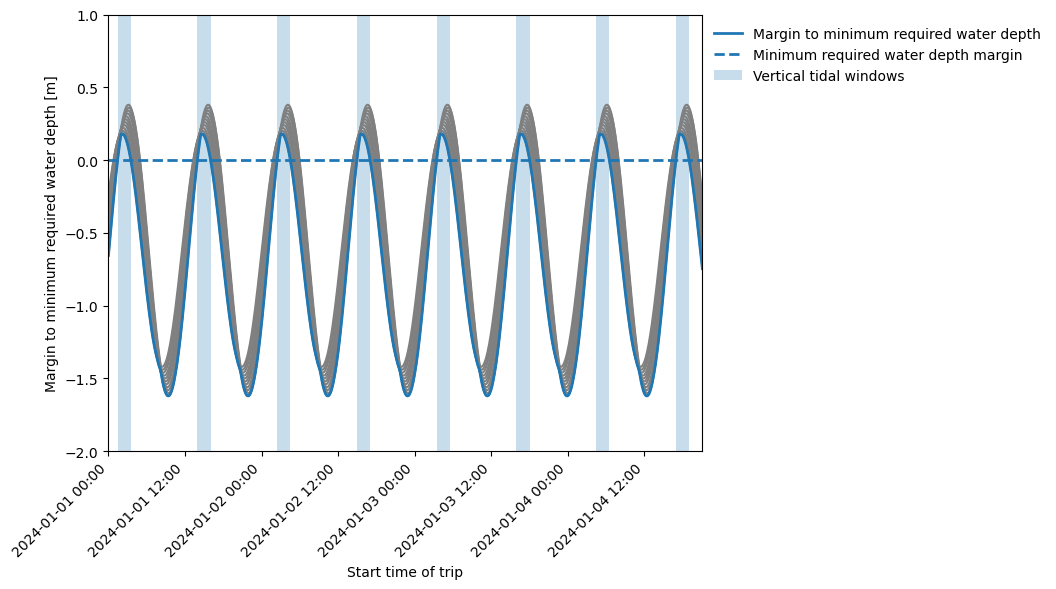

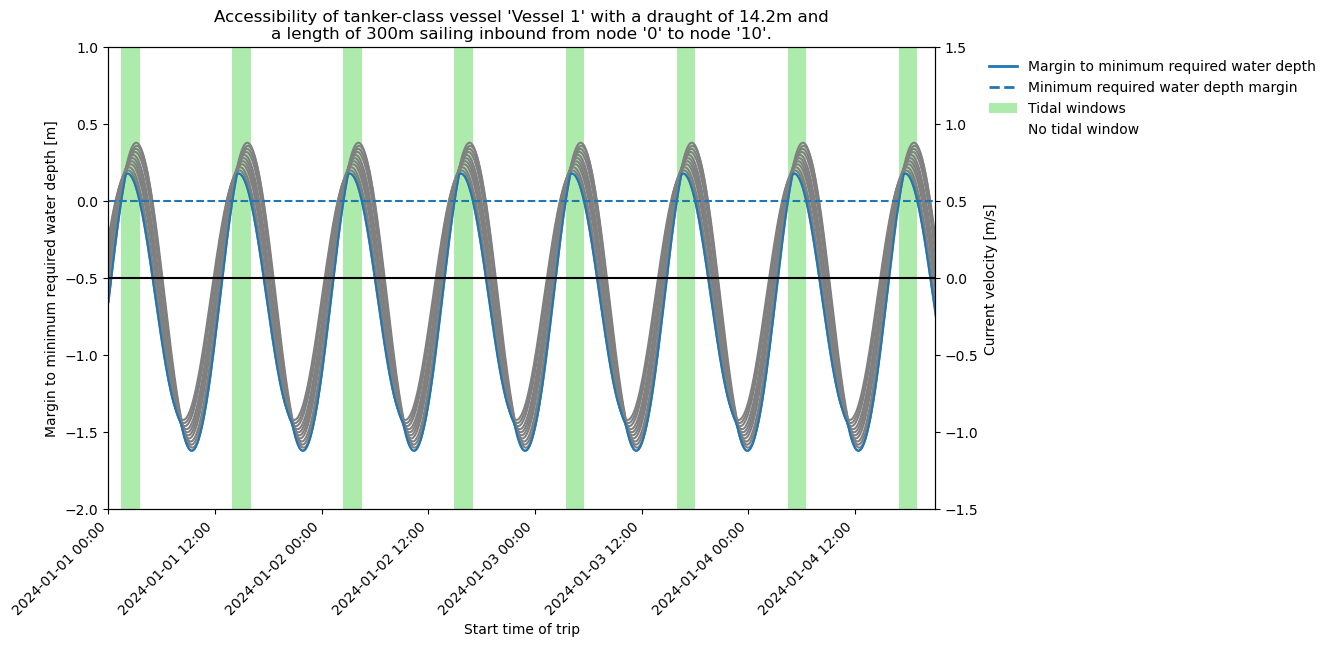

In [33]:
#Inbound trip
trip_index = 0
fig = vessel.plot_tidal_windows(trip_index=trip_index, plot_all = True)
fig

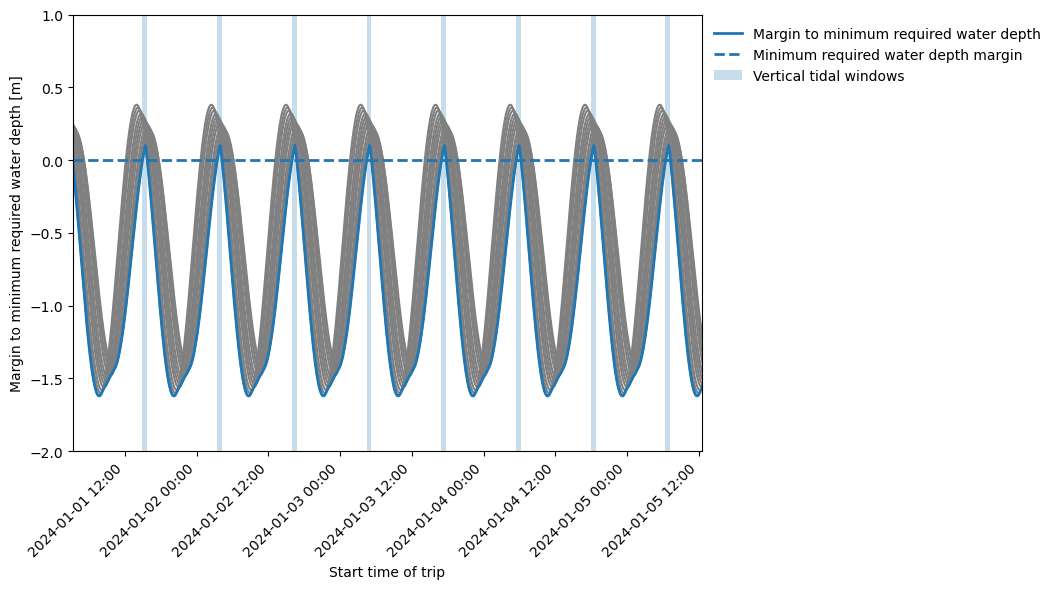

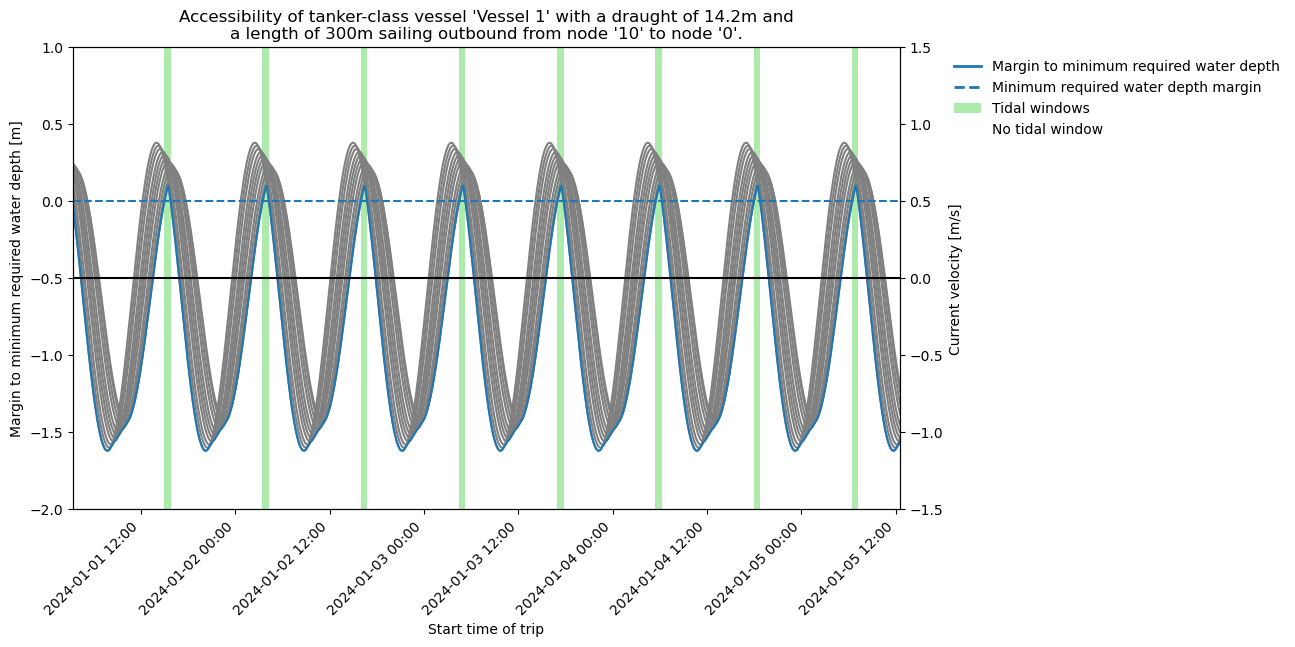

In [34]:
#Outbound trip
trip_index = 1
fig = vessel.plot_tidal_windows(trip_index=trip_index, plot_all = True)
fig

##### Getting accessibility information
We can calculate how accessible the port was, given the vessel trips:

In [35]:
inbound_accessibility_percentage = opentnsim.port.calculations.calculate_accessibility(vessel)
inbound_accessibility_percentage

number_of_tidal_windows                                    4
shortest_tidal_window_id                                   1
shortest_tidal_window_duration (s)           0 days 02:05:00
longest_tidal_window_id                                    1
longest_tidal_window_duration (s)            0 days 02:05:00
mean_tidal_window_duration (s)               0 days 02:05:00
accessibility_percentage (time %)                  17.361111
accessibility_percentage (tide %)                      200.0
causes_tidal_window (cause %)         {'Water level': 100.0}
dtype: object

In [36]:
outbound_accessibility_percentage = opentnsim.port.calculations.calculate_accessibility(vessel, trip_index=1)
outbound_accessibility_percentage

number_of_tidal_windows                                    3
shortest_tidal_window_id                                   2
shortest_tidal_window_duration (s)           0 days 00:50:00
longest_tidal_window_id                                    2
longest_tidal_window_duration (s)            0 days 00:50:00
mean_tidal_window_duration (s)               0 days 00:50:00
accessibility_percentage (time %)                   5.208333
accessibility_percentage (tide %)                 266.666667
causes_tidal_window (cause %)         {'Water level': 100.0}
dtype: object

##### Vessel trajectories
We can plot the vessel trajectories.

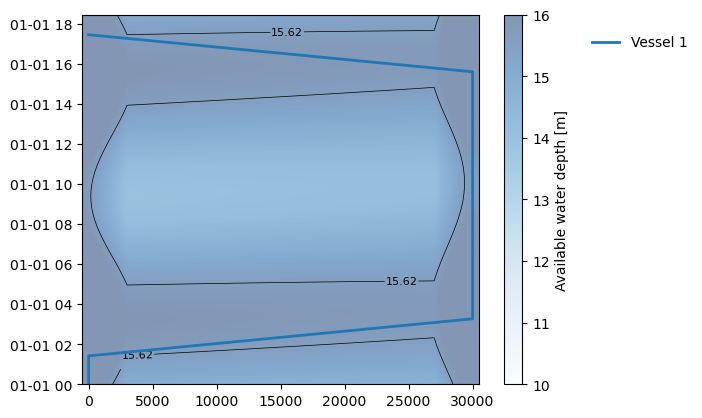

In [37]:
fig = port.plot_vessels(0, 10, levels=[vessel_draught*1.1], zmin=10,zmax=16)
fig